## LangChain中的Characte打extSplitter工具

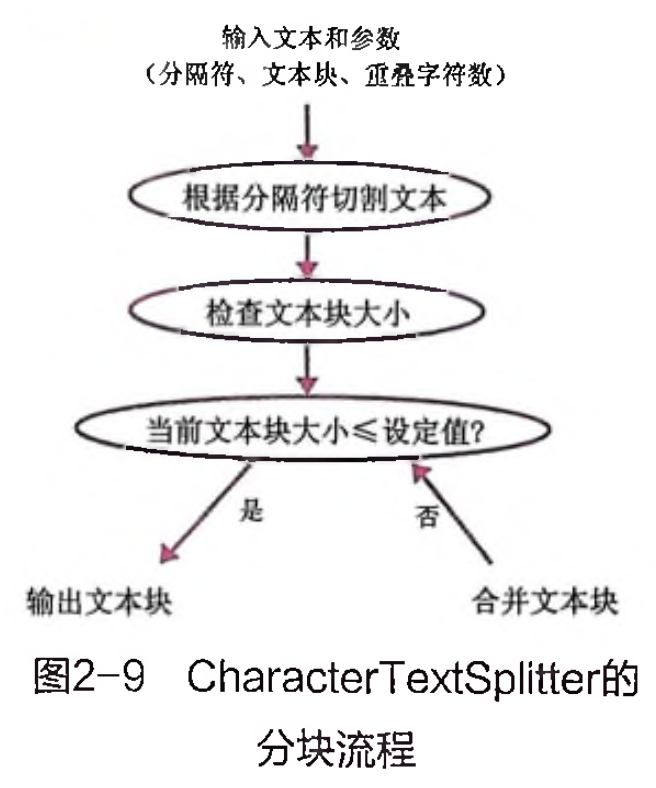

CharacterTextSplitter首先按照指定的字符分隔符（默认为“\n\n”,这是两个换行符， 即一个换行符加一个空行） 对文本进行分割， 然后不断地累加分割
后的片段， 并检查当前累积的文本是否超过了预设的大小限制。 如果超过限制， 就会开始一个新的块。 此外， CharacterTextSplitter允许设置块和块之间的重
叠字符数， 以便更好地捕捉信息间的关联。

In [1]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from llama_index.core.base.embeddings.base import similarity
from unstructured.chunking.dispatch import chunk

from RAG三问.langchain构建RAG简单示例 import text_splitter

loader=TextLoader("../data/山西文旅/云冈石窟.txt",encoding="utf-8")

documents=loader.load()

text_splitter=CharacterTextSplitter(
    chunk_size=50,
    chunk_overlap=0,
)

chunks=text_splitter.split_documents(documents)
chunks

加载了 2 个文档
分割成 22 个文本块

问题：《黑神话：悟空》中有那些故事章节



Created a chunk of size 216, which is longer than the specified 50
Created a chunk of size 100, which is longer than the specified 50
Created a chunk of size 193, which is longer than the specified 50
Created a chunk of size 87, which is longer than the specified 50
Created a chunk of size 162, which is longer than the specified 50
Created a chunk of size 120, which is longer than the specified 50
Created a chunk of size 67, which is longer than the specified 50
Created a chunk of size 128, which is longer than the specified 50


回答：《黑神话：悟空》的故事分为六个章节，分别是：“火照黑云”、“风起黄昏”、“夜生白露”、“曲度紫鸳”、“日落红尘”和“未竟”。


[Document(metadata={'source': '../data/山西文旅/云冈石窟.txt'}, page_content='云冈石窟\n云冈石窟位于中国北部山西省大同市西郊17公里处的武周山南麓，石窟依山开凿，东西绵延1公里。存有主要洞窟45个，大小窟龛252个，石雕造像51000余躯，为中国规模最大的古代石窟群之一，与敦煌莫高窟、洛阳龙门石窟和天水麦积山石窟并称为中国四大石窟艺术宝库。 1961年被国务院公布为全国首批重点文物保护单位，2001年12月14日被联合国教科文组织列入世界遗产名录，2007年5月8日被国家旅游局评为首批国家5A级旅游景区。'),
 Document(metadata={'source': '../data/山西文旅/云冈石窟.txt'}, page_content='云冈五华洞\n位于云冈石窟中部的第 9——13窟。这五窟因清代施泥彩绘云冈石窟景观而得名。五华洞雕饰绮丽，丰富多彩，是研究北魏历史、艺术、音乐、舞蹈、书法和建筑的珍贵资料，为云冈石窟群的重要组成部分。'),
 Document(metadata={'source': '../data/山西文旅/云冈石窟.txt'}, page_content='塔洞\n云冈东部窟群，指云冈石窟东端1——4，均为塔洞。第1、2窟为同期开的一组，凿于孝文帝迁洛前，窟内中央雕造方形塔柱，四面开龛造像。第一窟主像是弥勒，塔南面下层雕释迦多宝像，上层雕释迦像。浮雕五层小塔，是研究北魏建筑的形象资料。第二窟是释迦像，塔南面下层雕释迦多宝像，上层雕三世佛。两窟南壁窟门两侧都雕有维摩、文殊。第三窟为云冈石窟中规模最大的洞窟，前立壁高约25米，传为昙曜译经楼。'),
 Document(metadata={'source': '../data/山西文旅/云冈石窟.txt'}, page_content='武州山\n武周山，亦名武州山，在大同城西山中。宋《太平寰宇记》引《冀州图》云：“武周山在郡西北，东西数百里，南北五十里。山之南面，千仞壁立。”云冈石窟即因武周山南缘斩山开凿。'),
 Document(metadata={'source': '../data/山西文旅/云冈石窟.txt'}, page_content='昙曜五窟\n第十六至二十窟，是云冈石窟最早开业凿的五个洞窟，通称“昙曜五

### 创建Document

In [2]:
text="""
《黑神话：悟空》的故事可分为六个章节，名为“火照黑云”、“风起黄昏”、“夜生白露”、“曲度紫鸳”、“日落红尘”和“未竟”，并且拥有两个结局，玩家的选择和经历将影响最终的结局。

每个章节结尾，附有二维和三维的动画过场，展示和探索《黑神话：悟空》中的叙事和主题元素。

游戏的设定融合了中国的文化和自然地标。例如重庆的大足石刻、山西省的小西天、南禅寺、铁佛寺、广胜寺和鹳雀楼等，都在游戏中出现。游戏也融入了佛教和道教的哲学元素。
"""

text_splitter=CharacterTextSplitter(
    chunk_size=50,
    chunk_overlap=0,
    separator="\n",
)

chunks=text_splitter.create_documents([text])
chunks

Created a chunk of size 87, which is longer than the specified 50


[Document(metadata={}, page_content='《黑神话：悟空》的故事可分为六个章节，名为“火照黑云”、“风起黄昏”、“夜生白露”、“曲度紫鸳”、“日落红尘”和“未竟”，并且拥有两个结局，玩家的选择和经历将影响最终的结局。'),
 Document(metadata={}, page_content='每个章节结尾，附有二维和三维的动画过场，展示和探索《黑神话：悟空》中的叙事和主题元素。'),
 Document(metadata={}, page_content='游戏的设定融合了中国的文化和自然地标。例如重庆的大足石刻、山西省的小西天、南禅寺、铁佛寺、广胜寺和鹳雀楼等，都在游戏中出现。游戏也融入了佛教和道教的哲学元素。')]

使用split_text方法对文本字符串进行分割， 该方法只会返回分割后的纯文本片段， 也不会生成Document对象

In [3]:
chunks=text_splitter.split_text(text)
chunks


Created a chunk of size 87, which is longer than the specified 50


['《黑神话：悟空》的故事可分为六个章节，名为“火照黑云”、“风起黄昏”、“夜生白露”、“曲度紫鸳”、“日落红尘”和“未竟”，并且拥有两个结局，玩家的选择和经历将影响最终的结局。',
 '每个章节结尾，附有二维和三维的动画过场，展示和探索《黑神话：悟空》中的叙事和主题元素。',
 '游戏的设定融合了中国的文化和自然地标。例如重庆的大足石刻、山西省的小西天、南禅寺、铁佛寺、广胜寺和鹳雀楼等，都在游戏中出现。游戏也融入了佛教和道教的哲学元素。']

需要注意的是， 如果设定的文本块大小为1000个字符， 默认分隔符为“\n\n»,而某个段落的实际长度超过了这个限制（如1200个字符）,那么这种分割方式并不会切分该段落， 而是直接给出一个1200个字符的块， 并给出警告： “Created a chunk of size 1200, which is longer than the specified 1000”
 要解决这个问题， 建议使用RecursiveCharacterTextSplitter方法， 它能够更智能地处理这种情况， 确保每个块都不会超过指定的最大长度O

## 在Llamalndex中设置块大小参数

在LlamaIndex中， SimpleDirectoryReader能够在加载文档的同时直接进行分块操作,只需预先设置与分块相关的全局参数即可

In [5]:
import os
from llama_index.core import Settings, VectorStoreIndex
from llama_index.embeddings.dashscope import DashScopeEmbedding
from llama_index.llms.dashscope import DashScope

# 设置 DashScope API Key
os.environ["DASHSCOPE_API_KEY"] = "sk-51b422ad7151406b8c3ddb1ce0a424ba"  # 替换为你的真实 API Key

# 配置 Embedding 模型（用于文本向量化）
Settings.embed_model = DashScopeEmbedding(
    model_name="text-embedding-v3",
    api_key=os.environ["DASHSCOPE_API_KEY"]
)

# 配置 LLM 模型（用于问答生成）
Settings.llm = DashScope(
    model="qwen-turbo",
    api_key=os.environ["DASHSCOPE_API_KEY"]
)

# 其他设置
Settings.chunk_size = 512
Settings.chunk_overlap = 50

# 现在可以正常使用了
index = VectorStoreIndex.from_documents(documents)
query_engine = index.as_query_engine(similarity_top_k=4)
response = query_engine.query("云冈石窟位于何处？")
print(response)

云冈石窟位于中国北部山西省大同市西郊17公里处的武周山南麓。
